<a href="https://colab.research.google.com/github/be001/Personal-Projects-Portfolio/blob/main/LAB_2B_JsonAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Beniam Koffi

ID 1391422

Sep 20 2026

link to the notebook:https://colab.research.google.com/drive/1y-r4NtjKGX7p1EWNHYHiMp6HUHqFNM6Q?usp=sharing

# **A-  Load JSON Dataset**

In [ ]:
# importing the data

import pandas as pd
url = "https://data.cityofnewyork.us/resource/erm2-nwe9.json?$limit=10000"
df = pd.read_json(url)
df.head()


,unique_key,created_date,agency,agency_name,complaint_type,descriptor,incident_zip,incident_address,street_name,cross_street_1,...,vehicle_type,closed_date,descriptor_2,taxi_pick_up_location,bridge_highway_name,bridge_highway_segment,taxi_company_borough,bridge_highway_direction,road_ramp,due_date
0,70525336,2026-09-25T02:42:51.000,DOT,Department of Transportation,Street Condition,Pothole,11415.0,QUEENS BOULEVARD,QUEENS BOULEVARD,VWE NORTHBOUND EXIT 9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,70523865,2026-09-25T02:41:28.000,DOT,Department of Transportation,Street Condition,Pothole,11375.0,QUEENS BOULEVARD,QUEENS BOULEVARD,GREG STEIN WAY,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,70531134,2026-09-25T02:40:39.000,DOT,Department of Transportation,Street Condition,Pothole,11434.0,115 AVENUE,115 AVENUE,174 STREET,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,70526768,2026-09-25T02:39:37.000,DOT,Department of Transportation,Street Condition,Pothole,11434.0,LINDEN BOULEVARD,LINDEN BOULEVARD,115 AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,70532609,2026-09-25T02:38:25.000,DOT,Department of Transportation,Street Condition,Pothole,11434.0,LINDEN BOULEVARD,LINDEN BOULEVARD,LONG ISLAND RAILROAD,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# **B- Data Types**

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 48 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   unique_key                      10000 non-null  int64  
 1   created_date                    10000 non-null  object 
 2   agency                          10000 non-null  object 
 3   agency_name                     10000 non-null  object 
 4   complaint_type                  10000 non-null  object 
 5   descriptor                      10000 non-null  object 
 6   incident_zip                    9902 non-null   float64
 7   incident_address                9710 non-null   object 
 8   street_name                     9710 non-null   object 
 9   cross_street_1                  7175 non-null   object 
 10  cross_street_2                  7180 non-null   object 
 11  address_type                    9933 non-null   object 
 12  city                            9

In [ ]:
df.dtypes

,0
unique_key,int64
created_date,object
agency,object
agency_name,object
complaint_type,object
descriptor,object
incident_zip,float64
incident_address,object
street_name,object
cross_street_1,object


***Observation***: Overall, the DataFrame contains 1,000 rows and 48 columns. Representative column names include complaint_type, agency, and borough. The output of df.info() shows that these columns contain non-null values.The DataFrame consists of three distinct data types:
#####1-Integer (int64): Used for whole-number identifiers such as unique_key.
######2-Floating-point (float64): Used for decimal coordinates such as latitude and longitude.
#####3-Object/String (object): Used for text-based features such as borough and vehicle_type.

# Identifying data type category: text/categorical, date field and geographic coordonates

# Text/Categorical Fields

In [ ]:
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"\nColumn: {col}")
    print(df[col].value_counts(dropna=False))


Column: created_date
created_date
2026-09-24T08:44:02.000    10
2026-09-24T10:24:22.000    10
2026-09-24T18:01:09.000    10
2026-09-24T10:48:48.000    10
2026-09-24T19:15:30.000    10
                           ..
2026-09-24T17:45:47.000     1
2026-09-24T17:46:01.000     1
2026-09-24T17:46:07.000     1
2026-09-24T17:46:09.000     1
2026-09-24T17:44:00.000     1
Name: count, Length: 8174, dtype: int64

Column: agency
agency
NYPD     4049
HPD      2119
DSNY      932
DOT       758
DEP       600
DPR       521
DOB       347
DOHMH     248
DHS       209
TLC       104
DCWP       76
EDC        25
OOS        12
Name: count, dtype: int64

Column: agency_name
agency_name
New York City Police Department                       4049
Department of Housing Preservation and Development    2119
Department of Sanitation                               932
Department of Transportation                           758
Department of Environmental Protection                 600
Department of Parks and Recreation  

**Observation**: The unique values and counts of text in the categorical column were analyzed and some of the key findings are:
#####-Agencies: The alphabetical identifiers "NYPD" and "HPD" are the most frequently recorded text values with a count of 4049.
#####-Complaints: The literal text entries "Illegal Parking" and "Noise - Residential" appear more than any other issue description. The illegal parking has a count of 1664.
#####-Locations: Written names for Brooklyn, Queens, and Manhattan comprise the highest volume of categorical entries.
#####-Channels: The specific letter combinations "ONLINE", "PHONE", and "MOBILE" represent the primary request submission methods. The ONLINE has a count value of 5611.
#####-Other Text Fields: Columns storing word data (such as descriptor, status, and location_type) show a highly varied distribution of text descriptions.


# Date field

In [ ]:
# -------------------------------

# 2. Date Fields
# -------------------------------
date_cols = [col for col in df.columns if 'date' in col.lower()]
print("\nPotential Date Fields:")
print(date_cols)
# Convert date columns to datetime format
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')
print("\nDate Fields after conversion:")
print(df[date_cols].dtypes)



Potential Date Fields:
['created_date', 'resolution_action_updated_date', 'closed_date', 'due_date']

Date Fields after conversion:
created_date                      datetime64[ns]
resolution_action_updated_date    datetime64[ns]
closed_date                       datetime64[ns]
due_date                          datetime64[ns]
dtype: object


Date fields columns are 'created_date', 'resolution_action_updated_date', 'closed_date'and 'due_date', all of which track timelines for the service requests. Although Pandas initially loads these columns as the generic object (text) data type, they have been converted into datetime64, which is Python's specialized timestamp data type for time-series analysis.

# Geographic coordinates

In [ ]:


# -------------------------------
# 3. Geographic Coordinates
# -------------------------------
geo_cols = [col for col in df.columns
            if col.lower() in ['latitude', 'longitude', 'location']]
print("\nGeographic Coordinate Fields:")
print(geo_cols)
print('\nGeographic fields data types:')
print(df[geo_cols].dtypes)



Geographic Coordinate Fields:
['latitude', 'longitude', 'location']

Geographic fields data types:
latitude     float64
longitude    float64
location      object
dtype: object


***observation***: There are 3 geographic coordinate( latitude, longiture and location). Both latitude and longiture are float while the location is an object. The location information that can be used for mapping and geographic analysis.

# Missing Values

In [ ]:

# -------------------------------
# 4. Missing Values
# -------------------------------
print("\nMissing Values by Column:")
print(df.isnull().sum())



Missing Values by Column:
unique_key                           0
created_date                         0
agency                               0
agency_name                          0
complaint_type                       0
descriptor                           0
incident_zip                        98
incident_address                   290
street_name                        290
cross_street_1                    2825
cross_street_2                    2820
address_type                        67
city                               722
facility_type                     9655
status                               0
resolution_description            2983
resolution_action_updated_date    2961
community_board                      0
police_precinct                      0
borough                              0
open_data_channel_type               0
park_facility_name                   0
park_borough                         0
location_type                      761
intersection_street_1             275

### Missing Values Percentage

In [ ]:
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing_values, 'Missing Percentage': missing_percentage})
display(missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False))

,Missing Count,Missing Percentage
taxi_company_borough,9991,99.91
due_date,9987,99.87
road_ramp,9969,99.69
bridge_highway_direction,9968,99.68
bridge_highway_name,9944,99.44
bridge_highway_segment,9944,99.44
taxi_pick_up_location,9899,98.99
facility_type,9655,96.55
vehicle_type,9483,94.83
closed_date,5354,53.54


***observation***: The count and percentage of missing values for all columns were calculated and the top 3 features with the highest missing values are :
* -taxi_company_borough: 99.94% missing
* -due_date: 99.87% missing
* -road_ramp: 99.77% missing
* -bridge_highway_direction: 99.58% missing

# **C – Visualization & Insight Generation**

## C-1. Complaint Distribution-Top 10 Complaints

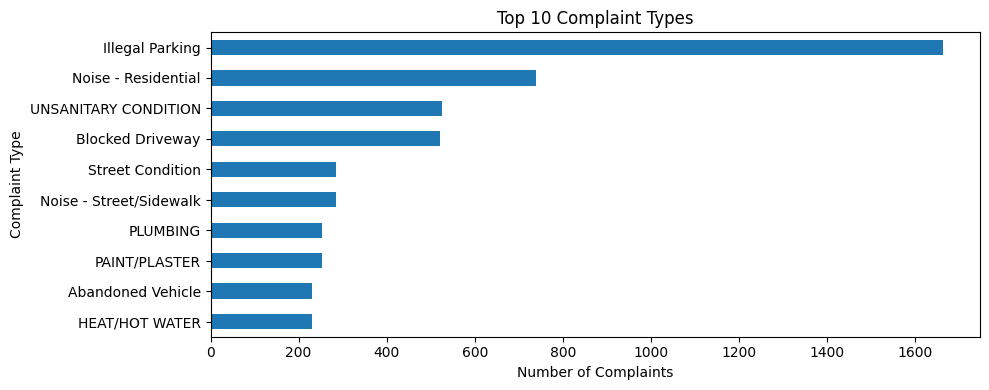

Most common complaint type: Illegal Parking
Number of complaints: 1664


In [ ]:
#Top 10 Complaint Types
import matplotlib.pyplot as plt
# -----------------------------------
top_complaints = df["complaint_type"].value_counts().head(10)
plt.figure(figsize=(10, 4))
top_complaints.sort_values().plot(kind="barh")
plt.title("Top 10 Complaint Types")
plt.xlabel("Number of Complaints")
plt.ylabel("Complaint Type")
plt.tight_layout()
plt.show()
print("Most common complaint type:", top_complaints.index[0])
print("Number of complaints:", top_complaints.iloc[0])


***Approach:*** To analyze the distribution of complaints, I used the complaint_type column and calculated the frequency of each complaint category using value_counts(). The top 10 most common complaint types were then visualized using a bar chart. This made it easier to compare the number of complaints across different categories and identify the most frequently reported issues.
#####***Observation:*** Most common complaint type is Illegal Parking with 1664 complaints. it's followed by residential noise and unsanitary condition.

## C-2 Borough Analysis-Service Counts

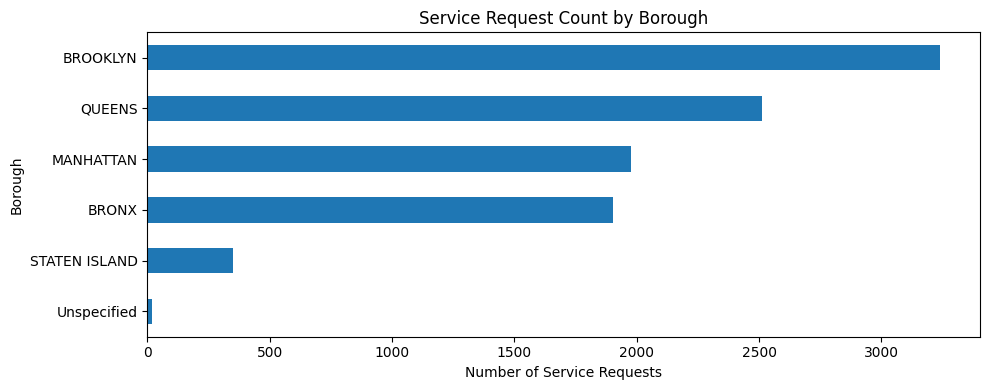

Most common borough: BROOKLYN
Number of service requests: 3241


In [ ]:
import matplotlib.pyplot as plt

borough_counts = df['borough'].value_counts()

plt.figure(figsize=(10, 4))
borough_counts.sort_values().plot(kind='barh')
plt.title('Service Request Count by Borough')
plt.xlabel('Number of Service Requests')
plt.ylabel('Borough')
plt.tight_layout()
plt.show()
print("Most common borough:", borough_counts.index[0])
print("Number of service requests:", borough_counts.iloc[0])


#####***approach:*** To analyze complaints by borough, I used the borough column and counted the number of complaints reported in each borough using the value_counts() function. The results were then displayed in a bar chart to compare complaint volumes across boroughs.

***observation:*** Brooklyn has the highest number of service requests with a total value of 3241. It's followed by Queens and Manhattan. Staten Island has the fewest requests.

## C-3 Complaints over time using time series analysis

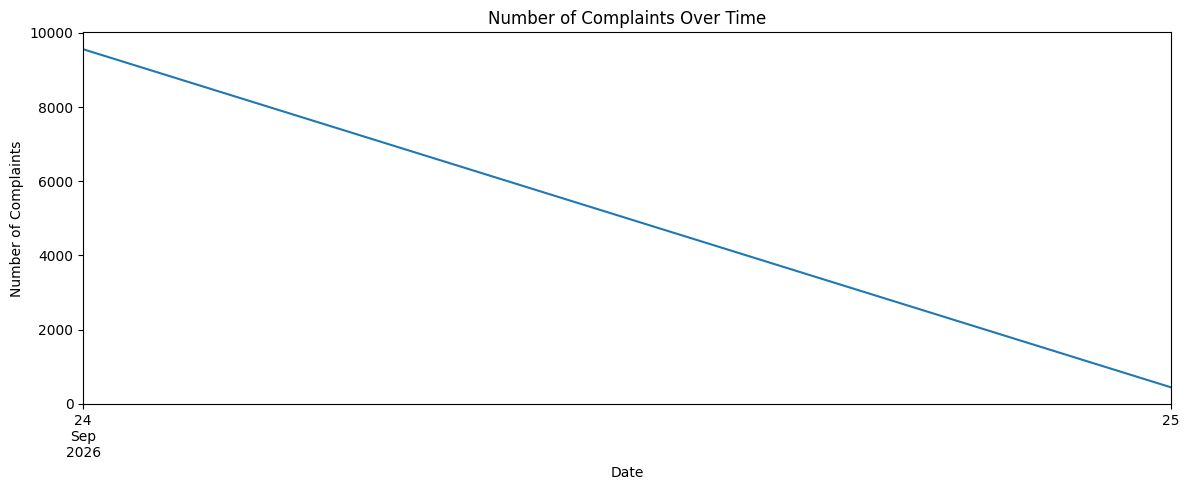

Date with the most complaints: 2026-09-24 00:00:00
Highest daily complaint count: 9558


In [ ]:
# 3. Complaints Over Time
# -----------------------------------
# Convert created_date to a datetime data type
df["created_date"] = pd.to_datetime(
    df["created_date"],
    errors="coerce"
)
# Remove missing dates and count complaints by day
daily_complaints = (
    df.dropna(subset=["created_date"])
      .set_index("created_date")
      .resample("D")
      .size()
)
plt.figure(figsize=(12, 5))
daily_complaints.plot()
plt.title("Number of Complaints Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Complaints")
plt.tight_layout()
plt.show()
print("Date with the most complaints:", daily_complaints.idxmax())
print("Highest daily complaint count:", daily_complaints.max())


#####***approach***: ***To analyze trends of complaints over time between 2026-09-24 and 2026-09-25, I used the created_date column, which records when each service request was submitted. First, I converted the column to a datetime format using pd.to_datetime(). Next, I grouped the complaints by date and counted the number of complaints submitted each day. Finally, I created a line chart to visualize how complaint activity changed over time.

***observation:*** The plot shows a significant peak in the number of complaints on 2026-09-24, with 9558 complaints, followed by a sharp decrease on 2026-09-25.

# **D – Identify Data Issues**

| Issue                      | Example                                                                                                  |
|:---------------------------|:---------------------------------------------------------------------------------------------------------|
| Missing Values             | Columns such as closed_date, latitude, longitude, and descriptor contain null or missing values.           |
| Inconsistent Date Formats  | Date fields such as created_date and closed_date have to be converted to a consistent datetime format using pd.to_datetime(). |
| Missing Geographic Information | Some records do not have valid latitude or longitude values, which can affect mapping and location-based analysis.     |

# **E – Mitigation Strategies:**


# Issue 1: Missing Values
**Approach:**
I identified columns with missing values using df.isnull().sum(). Depending on the column, missing values can be removed, filled with a default value, or replaced with the most common value.

**Pros:**
•	Improves data quality.
•	Reduces errors during analysis.
•	Makes the dataset more complete.

**Cons:**
•	Removing rows may reduce the amount of data available.
•	Filling missing values may introduce bias if not done carefully.

**Outcome:**
The dataset becomes cleaner and more reliable for analysis and visualization.
________________________________________
# Issue 2: Date Format Conversion
**Approach:**
I converted date columns such as created_date and closed_date to a datetime format using pd.to_datetime().

**Pros:**
•	Enables accurate time-series analysis.
•	Makes it easier to sort and filter records by date.
•	Supports trend analysis and reporting.
**Cons:**
•	Invalid date values may be converted to null values.
•	Additional preprocessing may be required.

**Outcome:**
The date fields can be analyzed correctly, allowing trends over time to be identified.
________________________________________
# Issue 3: Missing Geographic Coordinates
**Approach:**
I checked the latitude and longitude columns for missing values and removed or excluded records with incomplete location information when performing geographic analysis.

**Pros:**
•	Improves the accuracy of maps and location-based analysis.
•	Prevents plotting errors.

**Cons:**
•	Some records may be excluded from the analysis.
•	May reduce geographic coverage of the dataset.

**Outcome:**
Location-based visualizations and analyses become more accurate and reliable.


# **F – Store JSON Data into NoSQL Database**

In [ ]:
#Install TinyDB
!pip install tinydb
#_______________________________________
# Convert DataFrame into JSON Documents

# Convert Timestamp objects to ISO 8601 strings for JSON serialization, handling NaT values
import numpy as np
for col in df.select_dtypes(include=['datetime64[ns]']).columns:
    df[col] = df[col].apply(lambda x: x.isoformat() if pd.notna(x) else None)

records = df.to_dict(orient="records")
records[0]

#________________________________________
# Store Documents into NoSQL DB
#_________________________________
from tinydb import TinyDB, Query
db = TinyDB("nyc311_nosql.json")
db.truncate()
db.insert_multiple(records)
len(db)

10000

# **G – Query NoSQL Database**

# G-1 Find Noise Complaints

In [ ]:
from tinydb import Query
Complaint = Query()
noise_complaints = db.search(
    Complaint.complaint_type.matches(".*Noise.*")
)
print("Number of Noise Complaints:", len(noise_complaints))
# View first record
noise_complaints[:1]


Number of Noise Complaints: 1608


[{'unique_key': 70532174,
  'created_date': '2026-09-25T02:04:53',
  'agency': 'NYPD',
  'agency_name': 'New York City Police Department',
  'complaint_type': 'Noise - Street/Sidewalk',
  'descriptor': 'Loud Music/Party',
  'incident_zip': 11217.0,
  'incident_address': '426 BALTIC STREET',
  'street_name': 'BALTIC STREET',
  'cross_street_1': 'HOYT STREET',
  'cross_street_2': 'BOND STREET',
  'address_type': 'ADDRESS',
  'city': 'BROOKLYN',
  'facility_type': nan,
  'status': 'In Progress',
  'resolution_description': nan,
  'resolution_action_updated_date': None,
  'community_board': '06 BROOKLYN',
  'police_precinct': 'Precinct 76',
  'borough': 'BROOKLYN',
  'open_data_channel_type': 'MOBILE',
  'park_facility_name': 'Unspecified',
  'park_borough': 'BROOKLYN',
  'location_type': 'Street/Sidewalk',
  'intersection_street_1': 'HOYT STREET',
  'intersection_street_2': 'BOND STREET',
  'landmark': 'BALTIC STREET',
  'council_district': 39.0,
  'bbl': 3004040001.0,
  'x_coordinate_sta

**Approach:**
After storing the NYC 311 records in TinyDB, I queried the database to retrieve all complaints where the complaint_type contains the word "Noise". This allows us to focus specifically on noise-related service requests and analyze their frequency and characteristics.
#####**Pros:**
•	Makes it easy to retrieve a specific category of complaints.
•	TinyDB allows flexible searches without requiring a traditional SQL database.
•	Helps focus analysis on a particular issue affecting residents.
•	Query results can be further analyzed by borough, date, or location.
#####**Cons:**
•	Searches may miss records if complaint names are inconsistent or misspelled.
•	TinyDB is suitable for small datasets, but may become slower with very large datasets.
•	Some noise complaints may be classified under different descriptions.
#####**Outcome :** I queried the TinyDB database to find all complaints related to noise. The query filtered the dataset and returned only records where the complaint type contained the word "Noise." This makes it easier to focus on a specific category of service requests and analyze trends related to noise complaints.


# Find Brooklyn Complaints

In [ ]:
from tinydb import Query
Complaint = Query()
brooklyn_complaints = db.search(
    Complaint.borough == "BROOKLYN"
)
print("Number of Brooklyn Complaints:", len(brooklyn_complaints))
# View first record
brooklyn_complaints[:1]


Number of Brooklyn Complaints: 3241


[{'unique_key': 70532174,
  'created_date': '2026-09-25T02:04:53',
  'agency': 'NYPD',
  'agency_name': 'New York City Police Department',
  'complaint_type': 'Noise - Street/Sidewalk',
  'descriptor': 'Loud Music/Party',
  'incident_zip': 11217.0,
  'incident_address': '426 BALTIC STREET',
  'street_name': 'BALTIC STREET',
  'cross_street_1': 'HOYT STREET',
  'cross_street_2': 'BOND STREET',
  'address_type': 'ADDRESS',
  'city': 'BROOKLYN',
  'facility_type': nan,
  'status': 'In Progress',
  'resolution_description': nan,
  'resolution_action_updated_date': None,
  'community_board': '06 BROOKLYN',
  'police_precinct': 'Precinct 76',
  'borough': 'BROOKLYN',
  'open_data_channel_type': 'MOBILE',
  'park_facility_name': 'Unspecified',
  'park_borough': 'BROOKLYN',
  'location_type': 'Street/Sidewalk',
  'intersection_street_1': 'HOYT STREET',
  'intersection_street_2': 'BOND STREET',
  'landmark': 'BALTIC STREET',
  'council_district': 39.0,
  'bbl': 3004040001.0,
  'x_coordinate_sta

**approach:** After storing the NYC 311 records in TinyDB, I queried the database to retrieve all complaints where the borough field is equal to "BROOKLYN". This allows the analysis to focus specifically on service requests submitted from Brooklyn.
#####**Pros:**
•	Quickly retrieves complaints from a specific borough.
•	Makes it easier to perform location-based analysis.
•	Helps identify service issues affecting Brooklyn residents.
•	Results can be further analyzed by complaint type, date, or status.
#####**Cons:**
•	Records with missing or incorrect borough values may be excluded.
•	The query only focuses on one borough and does not provide city-wide comparisons.
•	TinyDB is suitable for small datasets but may be less efficient for very large datasets.
#####**Outcome**: I queried the TinyDB database to find all complaints reported in Brooklyn. By filtering on the borough field, I was able to retrieve only the records related to Brooklyn. This makes it easier to focus on a specific geographic area and analyze local service request trends.


# **Student Discussion Questions**

# 1.	Why is JSON suitable for semi-structured Big Data?
JSON is suitable for Big Data because it does not require a strict, permanent rulebook (schema). You can easily add new fields to any record at any time without breaking the rest of the database, making it perfect for handling massive amounts of fast-changing data.

# 2.	Why is a document NoSQL database appropriate for this dataset?
A document NoSQL database fits this dataset perfectly because it can save each 311 complaint as its own separate JSON file. This means the system can save thousands of complaints instantly without needing to link multiple tables together, making searches for things like complaint_type or borough more efficient and fast.

# 3.	What privacy concerns exist in public datasets?
Public datasets may still create privacy concerns because location information, timestamps, and other details combined can infer information about individuals. Organizations should remove sensitive data and follow privacy regulations before publishing datasets.

# 4.	How does NoSQL differ from relational databases in handling JSON data?
Relational databases require data to fit into predefined tables, while NoSQL databases can store JSON documents as they are. This flexibility makes NoSQL better suited for handling semi-structured data.

# 5.	What scalability advantages do NoSQL systems provide?
NoSQL systems provide scalability because they can distribute data across multiple servers instead of relying on a single machine. This allows them to manage large amounts of data efficiently and support Big Data applications that continue to grow over time.


AI was used for grammar and spellcheck as well as correcting the code

In [20]:
# 1. Install the required PDF conversion tools
!apt-get install texlive texlive-xetex texlive-latex-extra pandoc
!pip install jupyter lab nbconvert

# 2. Convert the notebook directly to a PDF
# Note: Replace 'Your_Notebook_Name.ipynb' with the exact name of your file
!jupyter nbconvert --to pdf "Lab2b_jason.ipynb"

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
pandoc is already the newest version (3.1.3+ds-2).
pandoc set to manually installed.
The following additional packages will be installed:
  at-spi2-common at-spi2-core default-jre default-jre-headless dvisvgm
  fonts-dejavu-core fonts-dejavu-extra fonts-dejavu-mono fonts-droid-fallback
  fonts-lato fonts-lmodern fonts-noto-mono fonts-texgyre fonts-texgyre-math
  fonts-urw-base35 gsettings-desktop-schemas libapache-pom-java
  libatk-bridge2.0-0t64 libatk-wrapper-java libatk-wrapper-java-jni
  libatk1.0-0t64 libatspi2.0-0t64 libbit-vector-perl libcarp-clan-perl
  libcommons-logging-java libcommons-parent-java libcrypt-rc4-perl
  libdate-calc-perl libdate-calc-xs-perl libdate-manip-perl
  libdigest-perl-md5-perl libfontbox-java libgs-common libgs10 libgs10-common
  libgtk-3-0t64 libgtk-3-bin libgtk-3-common libgumbo2 libidn12 libijs-0.35
  libio-stringy-perl libjbig2dec0 libjcode-pm-perl libkp

In [21]:
# 2. Convert the notebook directly to a PDF
# Note: Replace 'Your_Notebook_Name.ipynb' with the exact name of your file
!jupyter nbconvert --to pdf "Lab2b_jason.ipynb"

[NbConvertApp] WARNING | pattern 'Lab2b_jason.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=True]
--execute
   